# MS3SEG VentiMorph-RelNet V2.7 — Fold-0 Validation Evaluation

This notebook performs **evaluation only**.

It:

- loads the saved `best_model.pt`;
- never updates model weights;
- evaluates the 16 Fold-0 validation patients as complete 3D volumes;
- reports voxel-level and lesion-level metrics;
- calculates Dice, IoU, precision, recall, specificity, HD95 and ASSD;
- analyzes normal-WMH/abnormal-WMH confusion;
- measures periventricular abnormal-WMH false positives;
- creates patient-level CSV files and journal-ready figures;
- keeps the locked 20-patient test set disabled.

Required Kaggle inputs:

1. `MS3SEG`
2. `ms3seg-v27-best-checkpoint`

## Run instructions

1. In Kaggle **Settings**, select a **T4 GPU**.
2. Confirm both datasets are visible under **Input**.
3. Run the notebook with **Run All**.
4. Do not modify `RUN_LOCKED_TEST = False`.
5. After completion, download:

`/kaggle/working/MS3SEG_V27_FOLD0_VALIDATION_RESULTS.zip`

In [6]:
from __future__ import annotations

import os
import re
import gc
import json
import math
import random
import warnings
from functools import lru_cache
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy import ndimage
from scipy.optimize import linear_sum_assignment

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    warnings.warn(
        "A GPU is strongly recommended. Select a T4 GPU in Kaggle Settings."
    )

Device: cuda


In [7]:
def discover_ms3seg_root():
    required = {
        "MS_100_patient_preprocessed",
        "MS_100_patient_masks",
    }

    preferred = [
        Path("/kaggle/input/ms3seg/MS3SEG"),
        Path("/kaggle/input/ms3seg"),
        Path("/kaggle/input/datasets/saifsamiul/ms3seg/MS3SEG"),
    ]

    for candidate in preferred:
        if not candidate.exists():
            continue

        directory_names = {
            path.name
            for path in candidate.iterdir()
            if path.is_dir()
        }

        if required.issubset(directory_names):
            return candidate

    input_root = Path("/kaggle/input")

    for preprocessed_dir in input_root.rglob(
        "MS_100_patient_preprocessed"
    ):
        candidate = preprocessed_dir.parent

        if (
            candidate
            / "MS_100_patient_masks"
        ).exists():
            return candidate

    raise FileNotFoundError(
        "MS3SEG was not found. Add the MS3SEG dataset as a Kaggle input."
    )


def discover_checkpoint():
    input_root = Path("/kaggle/input")

    preferred = list(
        input_root.glob(
            "ms3seg-v27-best-checkpoint/**/best_model.pt"
        )
    )

    candidates = preferred or list(
        input_root.rglob("best_model.pt")
    )

    candidates = [
        path
        for path in candidates
        if path.is_file()
    ]

    if not candidates:
        raise FileNotFoundError(
            "best_model.pt was not found. Add "
            "ms3seg-v27-best-checkpoint as a Kaggle input."
        )

    candidates = sorted(
        candidates,
        key=lambda path: (
            "ms3seg-v27-best-checkpoint"
            in str(path).lower(),
            path.stat().st_size,
        ),
        reverse=True,
    )

    return candidates[0]


DATA_ROOT = discover_ms3seg_root()
CHECKPOINT_PATH = discover_checkpoint()
CHECKPOINT_DIR = CHECKPOINT_PATH.parent

PREPROCESSED_DIR = (
    DATA_ROOT
    / "MS_100_patient_preprocessed"
)

MASKS_DIR = (
    DATA_ROOT
    / "MS_100_patient_masks"
)

OUTPUT_DIR = Path(
    "/kaggle/working/MS3SEG_V27_FOLD0_VALIDATION"
)

FIGURE_DIR = OUTPUT_DIR / "figures"
PREDICTION_DIR = OUTPUT_DIR / "nifti_predictions"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATA_ROOT)
print("Checkpoint:", CHECKPOINT_PATH)
print("Output:", OUTPUT_DIR)

Dataset root: /kaggle/input/datasets/saifsamiul/ms3seg/MS3SEG
Checkpoint: /kaggle/input/datasets/saifsoft/ms3seg-v27-best-checkpoint/best_model.pt
Output: /kaggle/working/MS3SEG_V27_FOLD0_VALIDATION


In [8]:
mask_roots = [
    path
    for path in MASKS_DIR.iterdir()
    if path.is_dir()
]


def select_mask_root(kind):
    if kind == "vent":
        matches = [
            path
            for path in mask_roots
            if "vent" in path.name.lower()
        ]

    elif kind == "nwmh":
        matches = [
            path
            for path in mask_roots
            if (
                "nwmh" in path.name.lower()
                or "normal" in path.name.lower()
            )
            and "abwmh" not in path.name.lower()
            and "abnormal" not in path.name.lower()
        ]

    else:
        matches = [
            path
            for path in mask_roots
            if (
                "abwmh" in path.name.lower()
                or "abnormal" in path.name.lower()
            )
        ]

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one {kind} mask root, found: {matches}"
        )

    return matches[0]


VENT_ROOT = select_mask_root("vent")
NWMH_ROOT = select_mask_root("nwmh")
ABWMH_ROOT = select_mask_root("abwmh")


def find_unique_file(
    folder,
    patterns,
    description,
):
    found = []

    for pattern in patterns:
        found.extend(
            folder.glob(pattern)
        )

    unique = []
    seen = set()

    for path in found:
        if (
            path.is_file()
            and path not in seen
        ):
            unique.append(path)
            seen.add(path)

    if len(unique) != 1:
        raise FileNotFoundError(
            f"{description}: expected one file in {folder}; "
            f"found {len(unique)}: {unique}"
        )

    return unique[0]


patient_dirs = sorted(
    path
    for path in PREPROCESSED_DIR.iterdir()
    if (
        path.is_dir()
        and re.fullmatch(
            r"\d{3}",
            path.name,
        )
    )
)

records = []

for patient_dir in patient_dirs:
    patient_id = patient_dir.name

    records.append({
        "patient_id": patient_id,
        "flair": str(
            find_unique_file(
                patient_dir,
                [
                    f"{patient_id}_FLAIR.nii",
                    f"{patient_id}_FLAIR.nii.gz",
                ],
                f"{patient_id} FLAIR",
            )
        ),
        "t1": str(
            find_unique_file(
                patient_dir,
                [
                    f"{patient_id}_T1WI_reg.nii",
                    f"{patient_id}_T1WI_reg.nii.gz",
                    "*T1*reg*.nii*",
                ],
                f"{patient_id} T1",
            )
        ),
        "t2": str(
            find_unique_file(
                patient_dir,
                [
                    f"{patient_id}_T2WI_reg.nii",
                    f"{patient_id}_T2WI_reg.nii.gz",
                    "*T2*reg*.nii*",
                ],
                f"{patient_id} T2",
            )
        ),
        "vent": str(
            find_unique_file(
                VENT_ROOT / patient_id,
                [
                    f"{patient_id}_Vent_Mask.nii",
                    f"{patient_id}_Vent_Mask.nii.gz",
                    "*Vent*Mask*.nii*",
                ],
                f"{patient_id} ventricle mask",
            )
        ),
        "nwmh": str(
            find_unique_file(
                NWMH_ROOT / patient_id,
                [
                    f"{patient_id}_nWMH_Mask.nii",
                    f"{patient_id}_nWMH_Mask.nii.gz",
                    "*nWMH*Mask*.nii*",
                ],
                f"{patient_id} normal-WMH mask",
            )
        ),
        "abwmh": str(
            find_unique_file(
                ABWMH_ROOT / patient_id,
                [
                    f"{patient_id}_abWMH_Mask.nii",
                    f"{patient_id}_abWMH_Mask.nii.gz",
                    "*abWMH*Mask*.nii*",
                ],
                f"{patient_id} abnormal-WMH mask",
            )
        ),
    })


manifest = (
    pd.DataFrame(records)
    .sort_values("patient_id")
    .reset_index(drop=True)
)

manifest["patient_id"] = (
    manifest["patient_id"]
    .astype(str)
    .str.zfill(3)
)

manifest_by_id = manifest.set_index("patient_id")

print("Patients found:", len(manifest))

if len(manifest) != 100:
    warnings.warn(
        f"Expected 100 patients but found {len(manifest)}."
    )

display(manifest.head())

Patients found: 100


,patient_id,flair,t1,t2,vent,nwmh,abwmh
0,001,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
1,002,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
2,003,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
3,004,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
4,005,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...


In [9]:
split_candidates = list(
    CHECKPOINT_DIR.glob(
        "patient_level_5fold_split.csv"
    )
)

if not split_candidates:
    split_candidates = list(
        Path("/kaggle/input").rglob(
            "patient_level_5fold_split.csv"
        )
    )

if not split_candidates:
    raise FileNotFoundError(
        "patient_level_5fold_split.csv was not found in the checkpoint dataset."
    )

SPLIT_PATH = split_candidates[0]

split_df = pd.read_csv(
    SPLIT_PATH,
    dtype={
        "patient_id": str,
    },
)

split_df["patient_id"] = (
    split_df["patient_id"]
    .astype(str)
    .str.zfill(3)
)

required_columns = {
    "patient_id",
    "fold",
    "role",
}

missing_columns = (
    required_columns
    - set(split_df.columns)
)

if missing_columns:
    raise ValueError(
        f"Split file is missing columns: {sorted(missing_columns)}"
    )

FOLD = 0

validation_ids = (
    split_df.loc[
        (
            split_df["fold"]
            == FOLD
        )
        & (
            split_df["role"]
            == "val"
        ),
        "patient_id",
    ]
    .drop_duplicates()
    .tolist()
)

locked_test_ids = (
    split_df.loc[
        split_df["role"]
        == "test",
        "patient_id",
    ]
    .drop_duplicates()
    .tolist()
)

if len(validation_ids) != 16:
    raise ValueError(
        f"Expected 16 Fold-0 validation patients, found {len(validation_ids)}."
    )

if len(locked_test_ids) != 20:
    warnings.warn(
        f"Expected 20 locked-test patients, found {len(locked_test_ids)}."
    )

unknown_ids = (
    set(validation_ids)
    - set(manifest_by_id.index)
)

if unknown_ids:
    raise ValueError(
        f"Validation IDs absent from the dataset: {sorted(unknown_ids)}"
    )

print("Split file:", SPLIT_PATH)
print("Fold-0 validation patients:", validation_ids)
print("Locked-test patients detected but NOT evaluated:", len(locked_test_ids))

Split file: /kaggle/input/datasets/saifsoft/ms3seg-v27-best-checkpoint/patient_level_5fold_split.csv
Fold-0 validation patients: ['001', '007', '017', '018', '023', '034', '048', '053', '062', '064', '070', '072', '086', '089', '095', '099']
Locked-test patients detected but NOT evaluated: 20


In [10]:
@lru_cache(maxsize=48)
def load_volume(path):
    return np.asarray(
        nib.load(
            path,
            mmap=True,
        ).dataobj,
        dtype=np.float32,
    )


@lru_cache(maxsize=36)
def load_normalized_volume(path):
    array = load_volume(path).copy()

    finite = np.isfinite(array)
    nonzero = (
        finite
        & (
            np.abs(array)
            > 1e-6
        )
    )

    if nonzero.sum() < 100:
        return np.nan_to_num(
            array
        ).astype(np.float32)

    low, high = np.percentile(
        array[nonzero],
        [
            0.5,
            99.5,
        ],
    )

    high = max(
        high,
        low + 1.0,
    )

    array = np.clip(
        array,
        low,
        high,
    )

    array = (
        array
        - array[nonzero].mean()
    ) / (
        array[nonzero].std()
        + 1e-6
    )

    array[~finite] = 0.0

    return array.astype(
        np.float32
    )


@lru_cache(maxsize=48)
def load_binary_mask(path):
    return (
        load_volume(path)
        > 0
    ).astype(np.uint8)


def compose_target(row):
    ventricle = load_binary_mask(
        row.vent
    )

    normal_wmh = load_binary_mask(
        row.nwmh
    )

    abnormal_wmh = load_binary_mask(
        row.abwmh
    )

    target = np.zeros(
        ventricle.shape,
        dtype=np.uint8,
    )

    target[
        ventricle
        > 0
    ] = 1

    target[
        normal_wmh
        > 0
    ] = 2

    target[
        abnormal_wmh
        > 0
    ] = 3

    return target


def triplet(
    volume,
    slice_index,
):
    depth = volume.shape[2]

    indices = [
        max(
            0,
            slice_index - 1,
        ),
        slice_index,
        min(
            depth - 1,
            slice_index + 1,
        ),
    ]

    return np.stack(
        [
            volume[
                :,
                :,
                index,
            ]
            for index in indices
        ],
        axis=0,
    )


def build_patient_inputs(row):
    flair = load_normalized_volume(
        row.flair
    )

    t1 = load_normalized_volume(
        row.t1
    )

    t2 = load_normalized_volume(
        row.t2
    )

    depth = flair.shape[2]

    inputs = []

    for slice_index in range(depth):
        inputs.append(
            np.concatenate(
                [
                    triplet(
                        flair,
                        slice_index,
                    ),
                    triplet(
                        t1,
                        slice_index,
                    ),
                    triplet(
                        t2,
                        slice_index,
                    ),
                ],
                axis=0,
            )
        )

    return np.stack(
        inputs,
        axis=0,
    ).astype(np.float32)

In [11]:
class ConvNormAct(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
        k=3,
        stride=1,
        groups=1,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                k,
                stride=stride,
                padding=k // 2,
                groups=groups,
                bias=False,
            ),
            nn.GroupNorm(
                min(
                    8,
                    out_ch,
                ),
                out_ch,
            ),
            nn.SiLU(
                inplace=True
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


class ResidualBlock(nn.Module):
    def __init__(
        self,
        ch,
    ):
        super().__init__()

        self.c1 = ConvNormAct(
            ch,
            ch,
        )

        self.c2 = nn.Sequential(
            nn.Conv2d(
                ch,
                ch,
                3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(
                min(
                    8,
                    ch,
                ),
                ch,
            ),
        )

        self.act = nn.SiLU(
            inplace=True
        )

    def forward(
        self,
        x,
    ):
        return self.act(
            x
            + self.c2(
                self.c1(x)
            )
        )


class SE(nn.Module):
    def __init__(
        self,
        ch,
        r=8,
    ):
        super().__init__()

        hidden = max(
            8,
            ch // r,
        )

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(
                ch,
                hidden,
                1,
            ),
            nn.SiLU(
                inplace=True
            ),
            nn.Conv2d(
                hidden,
                ch,
                1,
            ),
            nn.Sigmoid(),
        )

    def forward(
        self,
        x,
    ):
        return x * self.net(x)


class ModalityStem(nn.Module):
    def __init__(
        self,
        out_ch,
    ):
        super().__init__()

        self.net = nn.Sequential(
            ConvNormAct(
                3,
                out_ch,
            ),
            ResidualBlock(
                out_ch
            ),
            SE(
                out_ch
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


class ModalityGatedFusion(nn.Module):
    def __init__(
        self,
        ch,
    ):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(
                ch * 3,
                max(
                    8,
                    ch // 2,
                ),
            ),
            nn.SiLU(
                inplace=True
            ),
            nn.Linear(
                max(
                    8,
                    ch // 2,
                ),
                3,
            ),
        )

        self.refine = ResidualBlock(
            ch
        )

    def forward(
        self,
        flair,
        t1,
        t2,
    ):
        pooled = torch.cat(
            [
                F.adaptive_avg_pool2d(
                    tensor,
                    1,
                ).flatten(1)
                for tensor in [
                    flair,
                    t1,
                    t2,
                ]
            ],
            dim=1,
        )

        weights = torch.softmax(
            self.gate(
                pooled
            ),
            dim=1,
        )

        fused = (
            weights[
                :,
                0,
                None,
                None,
                None,
            ]
            * flair
            + weights[
                :,
                1,
                None,
                None,
                None,
            ]
            * t1
            + weights[
                :,
                2,
                None,
                None,
                None,
            ]
            * t2
        )

        return (
            self.refine(
                fused
            ),
            weights,
        )


class DownBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
    ):
        super().__init__()

        self.net = nn.Sequential(
            ConvNormAct(
                in_ch,
                out_ch,
                stride=2,
            ),
            ResidualBlock(
                out_ch
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


class UpBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch,
    ):
        super().__init__()

        self.net = nn.Sequential(
            ConvNormAct(
                in_ch + skip_ch,
                out_ch,
            ),
            ResidualBlock(
                out_ch
            ),
        )

    def forward(
        self,
        x,
        skip,
    ):
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        return self.net(
            torch.cat(
                [
                    x,
                    skip,
                ],
                dim=1,
            )
        )


class AdaptiveAnisotropicContext(nn.Module):
    def __init__(
        self,
        ch,
    ):
        super().__init__()

        branch_ch = ch // 4

        self.reduce = ConvNormAct(
            ch,
            branch_ch,
            1,
        )

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(
                    branch_ch,
                    branch_ch,
                    3,
                    padding=dilation,
                    dilation=dilation,
                    groups=branch_ch,
                    bias=False,
                ),
                nn.GroupNorm(
                    min(
                        8,
                        branch_ch,
                    ),
                    branch_ch,
                ),
                nn.SiLU(
                    inplace=True
                ),
            )
            for dilation
            in (
                1,
                2,
                4,
                6,
            )
        ])

        self.mix = nn.Sequential(
            nn.Conv2d(
                branch_ch * 4,
                ch,
                1,
                bias=False,
            ),
            nn.GroupNorm(
                min(
                    8,
                    ch,
                ),
                ch,
            ),
            nn.SiLU(
                inplace=True
            ),
        )

        self.se = SE(ch)

    def forward(
        self,
        x,
    ):
        reduced = self.reduce(x)

        mixed = self.mix(
            torch.cat(
                [
                    branch(
                        reduced
                    )
                    for branch
                    in self.branches
                ],
                dim=1,
            )
        )

        return x + self.se(
            mixed
        )

In [12]:
class VentiMorphRefiner(nn.Module):
    def __init__(
        self,
        ch,
        mode: Literal[
            "none",
            "vent",
            "distance",
            "directional",
        ],
    ):
        super().__init__()

        self.mode = mode
        self.vent_head = nn.Conv2d(
            ch,
            1,
            1,
        )

        extras = {
            "none": 0,
            "vent": 1,
            "distance": 5,
            "directional": 9,
        }[
            mode
        ]

        self.orientation_head = (
            nn.Conv2d(
                ch,
                2,
                1,
            )
            if mode
            == "directional"
            else None
        )

        self.refine = (
            nn.Identity()
            if mode
            == "none"
            else nn.Sequential(
                ConvNormAct(
                    ch + extras,
                    ch,
                ),
                ResidualBlock(
                    ch
                ),
            )
        )

        sobel_x = torch.tensor([
            [
                -1.0,
                0.0,
                1.0,
            ],
            [
                -2.0,
                0.0,
                2.0,
            ],
            [
                -1.0,
                0.0,
                1.0,
            ],
        ]).view(
            1,
            1,
            3,
            3,
        )

        sobel_y = torch.tensor([
            [
                -1.0,
                -2.0,
                -1.0,
            ],
            [
                0.0,
                0.0,
                0.0,
            ],
            [
                1.0,
                2.0,
                1.0,
            ],
        ]).view(
            1,
            1,
            3,
            3,
        )

        self.register_buffer(
            "sobel_x",
            sobel_x,
        )

        self.register_buffer(
            "sobel_y",
            sobel_y,
        )

    def forward(
        self,
        feature,
    ):
        ventricle_logit = self.vent_head(
            feature
        )

        ventricle = torch.sigmoid(
            ventricle_logit
        )

        relation = {
            "vent_logits": ventricle_logit,
            "vent_prob": ventricle,
        }

        if self.mode == "none":
            return (
                feature,
                relation,
            )

        if self.mode == "vent":
            return (
                feature
                + self.refine(
                    torch.cat(
                        [
                            feature,
                            ventricle,
                        ],
                        dim=1,
                    )
                ),
                relation,
            )

        expansion_1 = F.max_pool2d(
            ventricle,
            7,
            1,
            3,
        )

        expansion_2 = F.max_pool2d(
            ventricle,
            21,
            1,
            10,
        )

        near = torch.clamp(
            expansion_1
            - ventricle,
            0,
            1,
        )

        middle = torch.clamp(
            expansion_2
            - expansion_1,
            0,
            1,
        )

        far = torch.clamp(
            1
            - expansion_2,
            0,
            1,
        )

        soft_distance = (
            0.2
            * near
            + 0.6
            * middle
            + far
        )

        relation.update({
            "near": near,
            "mid": middle,
            "far": far,
            "soft_distance": soft_distance,
        })

        extras = [
            ventricle,
            near,
            middle,
            far,
            soft_distance,
        ]

        if self.mode == "directional":
            normal = torch.cat(
                [
                    F.conv2d(
                        soft_distance,
                        self.sobel_x,
                        padding=1,
                    ),
                    F.conv2d(
                        soft_distance,
                        self.sobel_y,
                        padding=1,
                    ),
                ],
                dim=1,
            )

            normal = F.normalize(
                normal,
                dim=1,
                eps=1e-6,
            )

            orientation = F.normalize(
                self.orientation_head(
                    feature
                ),
                dim=1,
                eps=1e-6,
            )

            radial = torch.abs(
                (
                    normal
                    * orientation
                ).sum(
                    dim=1,
                    keepdim=True,
                )
            )

            tangential = 1 - radial

            relation.update({
                "normal_x": normal[
                    :,
                    0:1,
                ],
                "normal_y": normal[
                    :,
                    1:2,
                ],
                "orientation_x": orientation[
                    :,
                    0:1,
                ],
                "orientation_y": orientation[
                    :,
                    1:2,
                ],
                "radial": radial,
                "tangential": tangential,
            })

            extras += [
                normal[
                    :,
                    0:1,
                ],
                normal[
                    :,
                    1:2,
                ],
                radial,
                tangential,
            ]

        refined = feature + self.refine(
            torch.cat(
                [
                    feature,
                ]
                + extras,
                dim=1,
            )
        )

        return (
            refined,
            relation,
        )


class RelationConditionedPrototypeBank(nn.Module):
    def __init__(
        self,
        dim=32,
        temperature=0.1,
    ):
        super().__init__()

        self.temperature = temperature

        self.prototypes = nn.Parameter(
            F.normalize(
                torch.randn(
                    2,
                    3,
                    dim,
                ),
                dim=-1,
            )
        )


class VentiMorphRelNet(nn.Module):
    def __init__(
        self,
        base=24,
        num_classes=4,
        use_multimodal=True,
        use_context=True,
        guidance_mode="directional",
        use_prototypes=True,
        use_uncertainty=True,
        emb_dim=32,
    ):
        super().__init__()

        self.use_multimodal = use_multimodal
        self.use_prototypes = use_prototypes

        self.flair_stem = ModalityStem(base)
        self.t1_stem = ModalityStem(base)
        self.t2_stem = ModalityStem(base)

        self.fusion = ModalityGatedFusion(
            base
        )

        self.e0 = nn.Sequential(
            ConvNormAct(
                base,
                32,
            ),
            ResidualBlock(
                32
            ),
        )

        self.e1 = DownBlock(
            32,
            64,
        )

        self.e2 = DownBlock(
            64,
            128,
        )

        self.e3 = DownBlock(
            128,
            192,
        )

        self.e4 = DownBlock(
            192,
            256,
        )

        self.context = (
            AdaptiveAnisotropicContext(
                256
            )
            if use_context
            else ResidualBlock(
                256
            )
        )

        self.drop = nn.Dropout2d(
            0.1
        )

        self.d3 = UpBlock(
            256,
            192,
            192,
        )

        self.d2 = UpBlock(
            192,
            128,
            128,
        )

        self.d1 = UpBlock(
            128,
            64,
            64,
        )

        self.d0 = UpBlock(
            64,
            32,
            32,
        )

        self.mid_guide = VentiMorphRefiner(
            128,
            guidance_mode,
        )

        self.final_guide = VentiMorphRefiner(
            32,
            guidance_mode,
        )

        self.embedding = nn.Sequential(
            ConvNormAct(
                32,
                emb_dim,
            ),
            nn.Conv2d(
                emb_dim,
                emb_dim,
                1,
            ),
        )

        self.seg_head = nn.Conv2d(
            32,
            num_classes,
            1,
        )

        self.evidence_head = (
            nn.Conv2d(
                32,
                num_classes,
                1,
            )
            if use_uncertainty
            else None
        )

        self.prototype_bank = (
            RelationConditionedPrototypeBank(
                emb_dim
            )
            if use_prototypes
            else None
        )

    def forward(
        self,
        x,
    ):
        if (
            x.ndim != 4
            or x.shape[1] != 9
        ):
            raise ValueError(
                f"Expected [B,9,H,W], got {tuple(x.shape)}"
            )

        flair = self.flair_stem(
            x[
                :,
                0:3,
            ]
        )

        t1 = (
            self.t1_stem(
                x[
                    :,
                    3:6,
                ]
            )
            if self.use_multimodal
            else torch.zeros_like(
                flair
            )
        )

        t2 = (
            self.t2_stem(
                x[
                    :,
                    6:9,
                ]
            )
            if self.use_multimodal
            else torch.zeros_like(
                flair
            )
        )

        fused, weights = self.fusion(
            flair,
            t1,
            t2,
        )

        e0 = self.e0(
            fused
        )

        e1 = self.e1(
            e0
        )

        e2 = self.e2(
            e1
        )

        e3 = self.e3(
            e2
        )

        e4 = self.drop(
            self.context(
                self.e4(
                    e3
                )
            )
        )

        d3 = self.d3(
            e4,
            e3,
        )

        d2, middle_relation = self.mid_guide(
            self.d2(
                d3,
                e2,
            )
        )

        d1 = self.d1(
            d2,
            e1,
        )

        d0, final_relation = self.final_guide(
            self.d0(
                d1,
                e0,
            )
        )

        embedding = self.embedding(
            d0
        )

        logits = self.seg_head(
            d0
        )

        evidence = (
            F.softplus(
                self.evidence_head(
                    d0
                )
            )
            if self.evidence_head
            is not None
            else None
        )

        alpha = (
            evidence + 1
            if evidence
            is not None
            else None
        )

        uncertainty = (
            4.0
            / alpha.sum(
                dim=1,
                keepdim=True,
            )
            if alpha
            is not None
            else None
        )

        return {
            "segmentation_logits": logits,
            "embedding": embedding,
            "modality_weights": weights,
            "mid_relation": middle_relation,
            "final_relation": final_relation,
            "evidence": evidence,
            "alpha": alpha,
            "uncertainty": uncertainty,
        }

In [13]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

if "model_state" not in checkpoint:
    raise KeyError(
        "The checkpoint does not contain model_state."
    )

config = checkpoint.get(
    "config",
    {},
)

model = VentiMorphRelNet(
    base=int(
        config.get(
            "base",
            24,
        )
    ),
    use_multimodal=bool(
        config.get(
            "use_multimodal",
            True,
        )
    ),
    use_context=bool(
        config.get(
            "use_context",
            True,
        )
    ),
    guidance_mode=str(
        config.get(
            "guidance_mode",
            "directional",
        )
    ),
    use_prototypes=bool(
        config.get(
            "use_prototypes",
            True,
        )
    ),
    use_uncertainty=bool(
        config.get(
            "use_uncertainty",
            True,
        )
    ),
).to(DEVICE)

incompatible = model.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

model.eval()

for parameter in model.parameters():
    parameter.requires_grad_(False)

parameter_count = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)

print("Checkpoint epoch:", checkpoint.get("best_epoch"))
print("Recorded mean foreground Dice:", checkpoint.get("best_val_mean_fg_dice"))
print("Model parameters:", parameter_count)
print("Model loaded successfully:", incompatible)
print("All parameters frozen:", not any(
    parameter.requires_grad
    for parameter
    in model.parameters()
))

Checkpoint epoch: 47
Recorded mean foreground Dice: 0.7636768817901611
Model parameters: 5974441
Model loaded successfully: <All keys matched successfully>
All parameters frozen: True


In [14]:
INFERENCE_BATCH_SIZE = 4
SAVE_NIFTI_PREDICTIONS = False


@torch.inference_mode()
def predict_patient(
    patient_id,
):
    patient_id = str(
        patient_id
    ).zfill(3)

    row = manifest_by_id.loc[
        patient_id
    ]

    inputs = build_patient_inputs(
        row
    )

    probability_batches = []
    uncertainty_batches = []
    modality_weight_batches = []

    for start in range(
        0,
        len(inputs),
        INFERENCE_BATCH_SIZE,
    ):
        batch = torch.from_numpy(
            inputs[
                start:start
                + INFERENCE_BATCH_SIZE
            ]
        ).to(
            DEVICE
        )

        with torch.autocast(
            device_type=DEVICE.type,
            enabled=(
                DEVICE.type
                == "cuda"
            ),
        ):
            output = model(
                batch
            )

            probabilities = torch.softmax(
                output[
                    "segmentation_logits"
                ],
                dim=1,
            )

        probability_batches.append(
            probabilities
            .float()
            .cpu()
            .numpy()
        )

        uncertainty = output.get(
            "uncertainty"
        )

        if uncertainty is None:
            uncertainty = torch.zeros(
                (
                    batch.shape[0],
                    1,
                    batch.shape[2],
                    batch.shape[3],
                ),
                device=batch.device,
            )

        uncertainty_batches.append(
            uncertainty
            .float()
            .cpu()
            .numpy()
        )

        modality_weight_batches.append(
            output[
                "modality_weights"
            ]
            .float()
            .cpu()
            .numpy()
        )

        del batch
        del output
        del probabilities

    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    uncertainties = np.concatenate(
        uncertainty_batches,
        axis=0,
    )

    modality_weights = np.concatenate(
        modality_weight_batches,
        axis=0,
    )

    # [slice, class, x, y] -> [x, y, slice, class]
    probabilities = np.transpose(
        probabilities,
        (
            2,
            3,
            0,
            1,
        ),
    )

    # [slice, 1, x, y] -> [x, y, slice]
    uncertainties = np.transpose(
        uncertainties[
            :,
            0,
        ],
        (
            1,
            2,
            0,
        ),
    )

    prediction = np.argmax(
        probabilities,
        axis=-1,
    ).astype(np.uint8)

    target = compose_target(
        row
    )

    return {
        "patient_id": patient_id,
        "prediction": prediction,
        "target": target,
        "probabilities": probabilities.astype(np.float16),
        "uncertainty": uncertainties.astype(np.float16),
        "modality_weights": modality_weights,
    }

In [15]:
def safe_divide(
    numerator,
    denominator,
    empty_value=0.0,
):
    if denominator == 0:
        return float(
            empty_value
        )

    return float(
        numerator
        / denominator
    )


def binary_metrics(
    prediction,
    target,
):
    prediction = prediction.astype(
        bool
    )

    target = target.astype(
        bool
    )

    true_positive = int(
        (
            prediction
            & target
        ).sum()
    )

    false_positive = int(
        (
            prediction
            & ~target
        ).sum()
    )

    false_negative = int(
        (
            ~prediction
            & target
        ).sum()
    )

    true_negative = int(
        (
            ~prediction
            & ~target
        ).sum()
    )

    if (
        prediction.sum() == 0
        and target.sum() == 0
    ):
        dice = 1.0
        iou = 1.0
        precision = 1.0
        recall = 1.0

    else:
        dice = safe_divide(
            2
            * true_positive,
            2
            * true_positive
            + false_positive
            + false_negative,
        )

        iou = safe_divide(
            true_positive,
            true_positive
            + false_positive
            + false_negative,
        )

        precision = safe_divide(
            true_positive,
            true_positive
            + false_positive,
        )

        recall = safe_divide(
            true_positive,
            true_positive
            + false_negative,
        )

    specificity = safe_divide(
        true_negative,
        true_negative
        + false_positive,
        empty_value=1.0,
    )

    return {
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "tp": true_positive,
        "fp": false_positive,
        "fn": false_negative,
        "tn": true_negative,
    }


def surface_distances(
    prediction,
    target,
    spacing,
):
    prediction = prediction.astype(
        bool
    )

    target = target.astype(
        bool
    )

    if (
        not prediction.any()
        and not target.any()
    ):
        return np.array(
            [
                0.0,
            ],
            dtype=np.float64,
        )

    if (
        not prediction.any()
        or not target.any()
    ):
        return np.array(
            [
                np.nan,
            ],
            dtype=np.float64,
        )

    structure = ndimage.generate_binary_structure(
        3,
        1,
    )

    prediction_surface = (
        prediction
        ^ ndimage.binary_erosion(
            prediction,
            structure=structure,
            border_value=0,
        )
    )

    target_surface = (
        target
        ^ ndimage.binary_erosion(
            target,
            structure=structure,
            border_value=0,
        )
    )

    target_distance = ndimage.distance_transform_edt(
        ~target_surface,
        sampling=spacing,
    )

    prediction_distance = ndimage.distance_transform_edt(
        ~prediction_surface,
        sampling=spacing,
    )

    distances = np.concatenate([
        target_distance[
            prediction_surface
        ],
        prediction_distance[
            target_surface
        ],
    ])

    return distances.astype(
        np.float64
    )


def distance_metrics(
    prediction,
    target,
    spacing,
):
    distances = surface_distances(
        prediction,
        target,
        spacing,
    )

    if np.isnan(
        distances
    ).all():
        return {
            "hd95_mm": np.nan,
            "assd_mm": np.nan,
        }

    return {
        "hd95_mm": float(
            np.nanpercentile(
                distances,
                95,
            )
        ),
        "assd_mm": float(
            np.nanmean(
                distances
            )
        ),
    }


def connected_components(
    mask,
    minimum_voxels=3,
):
    structure = ndimage.generate_binary_structure(
        3,
        2,
    )

    labels, number = ndimage.label(
        mask.astype(bool),
        structure=structure,
    )

    components = []

    for component_id in range(
        1,
        number + 1,
    ):
        component = (
            labels
            == component_id
        )

        size = int(
            component.sum()
        )

        if size >= minimum_voxels:
            components.append({
                "mask": component,
                "voxels": size,
            })

    return components


def lesion_matching_metrics(
    prediction,
    target,
    minimum_voxels=3,
    iou_threshold=0.10,
):
    predicted_components = connected_components(
        prediction,
        minimum_voxels,
    )

    target_components = connected_components(
        target,
        minimum_voxels,
    )

    number_predicted = len(
        predicted_components
    )

    number_target = len(
        target_components
    )

    if (
        number_predicted == 0
        and number_target == 0
    ):
        return {
            "lesion_sensitivity": 1.0,
            "lesion_precision": 1.0,
            "lesion_f1": 1.0,
            "true_lesions": 0,
            "predicted_lesions": 0,
            "matched_lesions": 0,
            "false_positive_lesions": 0,
            "small_lesion_recall": np.nan,
            "medium_lesion_recall": np.nan,
            "large_lesion_recall": np.nan,
        }

    if (
        number_predicted == 0
        or number_target == 0
    ):
        matched_target_indices = set()

    else:
        iou_matrix = np.zeros(
            (
                number_target,
                number_predicted,
            ),
            dtype=np.float64,
        )

        for target_index, target_component in enumerate(
            target_components
        ):
            target_mask = target_component[
                "mask"
            ]

            for predicted_index, predicted_component in enumerate(
                predicted_components
            ):
                predicted_mask = predicted_component[
                    "mask"
                ]

                intersection = int(
                    (
                        target_mask
                        & predicted_mask
                    ).sum()
                )

                union = int(
                    (
                        target_mask
                        | predicted_mask
                    ).sum()
                )

                if union > 0:
                    iou_matrix[
                        target_index,
                        predicted_index,
                    ] = (
                        intersection
                        / union
                    )

        target_indices, predicted_indices = linear_sum_assignment(
            -iou_matrix
        )

        valid_matches = [
            (
                target_index,
                predicted_index,
            )
            for target_index, predicted_index
            in zip(
                target_indices,
                predicted_indices,
            )
            if iou_matrix[
                target_index,
                predicted_index,
            ]
            >= iou_threshold
        ]

        matched_target_indices = {
            target_index
            for target_index, _
            in valid_matches
        }

    matched_lesions = len(
        matched_target_indices
    )

    sensitivity = safe_divide(
        matched_lesions,
        number_target,
        empty_value=1.0,
    )

    precision = safe_divide(
        matched_lesions,
        number_predicted,
        empty_value=(
            1.0
            if number_target == 0
            else 0.0
        ),
    )

    lesion_f1 = safe_divide(
        2
        * precision
        * sensitivity,
        precision
        + sensitivity,
    )

    size_groups = {
        "small": [],
        "medium": [],
        "large": [],
    }

    for target_index, component in enumerate(
        target_components
    ):
        voxels = component[
            "voxels"
        ]

        if voxels <= 20:
            group = "small"

        elif voxels <= 100:
            group = "medium"

        else:
            group = "large"

        size_groups[
            group
        ].append(
            target_index
        )

    size_recall = {}

    for group, indices in size_groups.items():
        if not indices:
            size_recall[
                group
            ] = np.nan

        else:
            detected = sum(
                index
                in matched_target_indices
                for index
                in indices
            )

            size_recall[
                group
            ] = (
                detected
                / len(indices)
            )

    return {
        "lesion_sensitivity": sensitivity,
        "lesion_precision": precision,
        "lesion_f1": lesion_f1,
        "true_lesions": number_target,
        "predicted_lesions": number_predicted,
        "matched_lesions": matched_lesions,
        "false_positive_lesions": max(
            0,
            number_predicted
            - matched_lesions,
        ),
        "small_lesion_recall": size_recall[
            "small"
        ],
        "medium_lesion_recall": size_recall[
            "medium"
        ],
        "large_lesion_recall": size_recall[
            "large"
        ],
    }


def periventricular_fp_rate(
    predicted_abnormal,
    true_abnormal,
    true_ventricle,
    spacing_xy,
    maximum_distance_mm=10.0,
):
    distance = np.zeros_like(
        true_ventricle,
        dtype=np.float32,
    )

    for slice_index in range(
        true_ventricle.shape[2]
    ):
        distance[
            :,
            :,
            slice_index,
        ] = ndimage.distance_transform_edt(
            ~true_ventricle[
                :,
                :,
                slice_index,
            ].astype(bool),
            sampling=spacing_xy,
        )

    periventricular_region = (
        distance
        <= maximum_distance_mm
    ) & (
        ~true_ventricle.astype(bool)
    )

    periventricular_predictions = (
        predicted_abnormal
        & periventricular_region
    )

    false_positive = (
        predicted_abnormal
        & ~true_abnormal
        & periventricular_region
    )

    return safe_divide(
        int(
            false_positive.sum()
        ),
        int(
            periventricular_predictions.sum()
        ),
        empty_value=0.0,
    )


def update_confusion_matrix(
    confusion_matrix,
    target,
    prediction,
):
    encoded = (
        target.astype(np.int64)
        * 4
        + prediction.astype(np.int64)
    )

    counts = np.bincount(
        encoded.ravel(),
        minlength=16,
    ).reshape(
        4,
        4,
    )

    confusion_matrix += counts

In [16]:
RUN_LOCKED_TEST = False

if RUN_LOCKED_TEST:
    raise RuntimeError(
        "Locked-test evaluation is intentionally disabled. "
        "Complete validation analysis and freeze all settings first."
    )


CLASS_INFORMATION = {
    1: "ventricle",
    2: "normal_wmh",
    3: "abnormal_wmh",
}

patient_rows = []
lesion_rows = []
validation_cache = {}

global_confusion = np.zeros(
    (
        4,
        4,
    ),
    dtype=np.int64,
)


for patient_number, patient_id in enumerate(
    validation_ids,
    start=1,
):
    result = predict_patient(
        patient_id
    )

    prediction = result[
        "prediction"
    ]

    target = result[
        "target"
    ]

    uncertainty = result[
        "uncertainty"
    ].astype(np.float32)

    row = manifest_by_id.loc[
        patient_id
    ]

    reference_image = nib.load(
        row.flair,
        mmap=True,
    )

    spacing = tuple(
        float(value)
        for value
        in reference_image.header.get_zooms()[
            :3
        ]
    )

    update_confusion_matrix(
        global_confusion,
        target,
        prediction,
    )

    patient_metrics = {
        "patient_id": patient_id,
        "fold": FOLD,
        "split": "validation",
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2],
    }

    for class_id, class_name in CLASS_INFORMATION.items():
        predicted_class = (
            prediction
            == class_id
        )

        target_class = (
            target
            == class_id
        )

        overlap = binary_metrics(
            predicted_class,
            target_class,
        )

        distance = distance_metrics(
            predicted_class,
            target_class,
            spacing,
        )

        for metric_name, metric_value in {
            **overlap,
            **distance,
        }.items():
            patient_metrics[
                f"{class_name}_{metric_name}"
            ] = metric_value

        if class_id in (
            2,
            3,
        ):
            lesion = lesion_matching_metrics(
                predicted_class,
                target_class,
                minimum_voxels=3,
                iou_threshold=0.10,
            )

            lesion_row = {
                "patient_id": patient_id,
                "class_id": class_id,
                "class_name": class_name,
                **lesion,
            }

            lesion_rows.append(
                lesion_row
            )

            for metric_name, metric_value in lesion.items():
                patient_metrics[
                    f"{class_name}_{metric_name}"
                ] = metric_value

    patient_metrics[
        "normal_as_abnormal_voxels"
    ] = int(
        (
            (
                target
                == 2
            )
            & (
                prediction
                == 3
            )
        ).sum()
    )

    patient_metrics[
        "abnormal_as_normal_voxels"
    ] = int(
        (
            (
                target
                == 3
            )
            & (
                prediction
                == 2
            )
        ).sum()
    )

    patient_metrics[
        "ventricle_as_wmh_voxels"
    ] = int(
        (
            (
                target
                == 1
            )
            & (
                (
                    prediction
                    == 2
                )
                | (
                    prediction
                    == 3
                )
            )
        ).sum()
    )

    true_ventricle = load_binary_mask(
        row.vent
    ).astype(bool)

    patient_metrics[
        "periventricular_abnormal_fp_rate"
    ] = periventricular_fp_rate(
        prediction
        == 3,
        target
        == 3,
        true_ventricle,
        spacing[
            :2
        ],
    )

    error_mask = (
        prediction
        != target
    )

    patient_metrics[
        "mean_uncertainty"
    ] = float(
        uncertainty.mean()
    )

    patient_metrics[
        "mean_uncertainty_error"
    ] = (
        float(
            uncertainty[
                error_mask
            ].mean()
        )
        if error_mask.any()
        else 0.0
    )

    patient_metrics[
        "mean_uncertainty_correct"
    ] = (
        float(
            uncertainty[
                ~error_mask
            ].mean()
        )
        if (
            ~error_mask
        ).any()
        else np.nan
    )

    patient_metrics[
        "mean_foreground_dice"
    ] = float(
        np.mean([
            patient_metrics[
                "ventricle_dice"
            ],
            patient_metrics[
                "normal_wmh_dice"
            ],
            patient_metrics[
                "abnormal_wmh_dice"
            ],
        ])
    )

    patient_rows.append(
        patient_metrics
    )

    validation_cache[
        patient_id
    ] = {
        "prediction": prediction,
        "target": target,
        "probabilities": result[
            "probabilities"
        ],
        "uncertainty": result[
            "uncertainty"
        ],
        "modality_weights": result[
            "modality_weights"
        ],
    }

    if SAVE_NIFTI_PREDICTIONS:
        prediction_image = nib.Nifti1Image(
            prediction.astype(
                np.uint8
            ),
            reference_image.affine,
            reference_image.header,
        )

        nib.save(
            prediction_image,
            PREDICTION_DIR
            / f"{patient_id}_prediction.nii.gz",
        )

    print(
        f"[{patient_number:02d}/{len(validation_ids)}] "
        f"{patient_id} | "
        f"FG Dice={patient_metrics['mean_foreground_dice']:.4f} | "
        f"V={patient_metrics['ventricle_dice']:.4f} | "
        f"N={patient_metrics['normal_wmh_dice']:.4f} | "
        f"A={patient_metrics['abnormal_wmh_dice']:.4f}"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


patient_metrics_df = pd.DataFrame(
    patient_rows
)

lesion_metrics_df = pd.DataFrame(
    lesion_rows
)

patient_metrics_df.to_csv(
    OUTPUT_DIR
    / "fold0_validation_patient_metrics.csv",
    index=False,
)

lesion_metrics_df.to_csv(
    OUTPUT_DIR
    / "fold0_validation_lesion_metrics.csv",
    index=False,
)

confusion_df = pd.DataFrame(
    global_confusion,
    index=[
        "true_background",
        "true_ventricle",
        "true_normal_wmh",
        "true_abnormal_wmh",
    ],
    columns=[
        "pred_background",
        "pred_ventricle",
        "pred_normal_wmh",
        "pred_abnormal_wmh",
    ],
)

confusion_df.to_csv(
    OUTPUT_DIR
    / "fold0_validation_confusion_matrix.csv"
)

print("\nValidation evaluation completed.")
display(patient_metrics_df.head())

[01/16] 001 | FG Dice=0.7873 | V=0.8266 | N=0.7362 | A=0.7991
[02/16] 007 | FG Dice=0.7281 | V=0.8690 | N=0.6866 | A=0.6288
[03/16] 017 | FG Dice=0.6372 | V=0.8252 | N=0.5187 | A=0.5677
[04/16] 018 | FG Dice=0.8014 | V=0.8782 | N=0.7101 | A=0.8160
[05/16] 023 | FG Dice=0.7437 | V=0.8493 | N=0.6205 | A=0.7613
[06/16] 034 | FG Dice=0.8035 | V=0.8597 | N=0.7028 | A=0.8481
[07/16] 048 | FG Dice=0.7296 | V=0.8119 | N=0.5645 | A=0.8125
[08/16] 053 | FG Dice=0.7966 | V=0.8678 | N=0.6887 | A=0.8331
[09/16] 062 | FG Dice=0.7316 | V=0.8697 | N=0.4884 | A=0.8369
[10/16] 064 | FG Dice=0.7877 | V=0.8402 | N=0.6961 | A=0.8267
[11/16] 070 | FG Dice=0.7959 | V=0.8816 | N=0.6755 | A=0.8305
[12/16] 072 | FG Dice=0.7062 | V=0.8717 | N=0.5215 | A=0.7254
[13/16] 086 | FG Dice=0.7061 | V=0.8135 | N=0.6382 | A=0.6667
[14/16] 089 | FG Dice=0.7644 | V=0.8601 | N=0.5763 | A=0.8568
[15/16] 095 | FG Dice=0.7849 | V=0.8231 | N=0.6513 | A=0.8803
[16/16] 099 | FG Dice=0.7791 | V=0.8779 | N=0.7025 | A=0.7571

Validat

,patient_id,fold,split,spacing_x,spacing_y,spacing_z,ventricle_dice,ventricle_iou,ventricle_precision,ventricle_recall,...,abnormal_wmh_medium_lesion_recall,abnormal_wmh_large_lesion_recall,normal_as_abnormal_voxels,abnormal_as_normal_voxels,ventricle_as_wmh_voxels,periventricular_abnormal_fp_rate,mean_uncertainty,mean_uncertainty_error,mean_uncertainty_correct,mean_foreground_dice
0,001,0,validation,0.8984,0.8984,6.800001,0.826625,0.704485,0.734093,0.945850,...,1.000000,1.000000,78,14,7,0.577670,0.193223,0.112768,0.193390,0.787310
1,007,0,validation,0.8984,0.8984,6.500000,0.868974,0.768306,0.853544,0.884972,...,1.000000,NaN,138,10,54,0.541562,0.193264,0.119537,0.193435,0.728133
2,017,0,validation,0.8984,0.8984,7.200000,0.825240,0.702475,0.926033,0.744234,...,0.611111,0.857143,2,345,85,0.135611,0.193266,0.143309,0.193517,0.637213
3,018,0,validation,0.8984,0.8984,6.200000,0.878185,0.782825,0.828311,0.934449,...,1.000000,1.000000,41,24,54,0.348649,0.193778,0.110326,0.193958,0.801435
4,023,0,validation,0.8984,0.8984,6.400001,0.849262,0.738014,0.787671,0.921301,...,0.769231,1.000000,437,225,90,0.295814,0.194797,0.108089,0.195077,0.743705


In [17]:
summary_rows = []

for class_name in [
    "ventricle",
    "normal_wmh",
    "abnormal_wmh",
]:
    for metric_name in [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity",
        "hd95_mm",
        "assd_mm",
    ]:
        column = (
            f"{class_name}_{metric_name}"
        )

        values = pd.to_numeric(
            patient_metrics_df[
                column
            ],
            errors="coerce",
        )

        summary_rows.append({
            "class": class_name,
            "metric": metric_name,
            "mean": values.mean(),
            "std": values.std(
                ddof=1
            ),
            "median": values.median(),
            "minimum": values.min(),
            "maximum": values.max(),
            "valid_patients": int(
                values.notna().sum()
            ),
        })


summary_df = pd.DataFrame(
    summary_rows
)

summary_df.to_csv(
    OUTPUT_DIR
    / "fold0_validation_class_summary.csv",
    index=False,
)


overall_summary = pd.DataFrame([
    {
        "metric": "mean_patient_foreground_dice",
        "value": patient_metrics_df[
            "mean_foreground_dice"
        ].mean(),
    },
    {
        "metric": "std_patient_foreground_dice",
        "value": patient_metrics_df[
            "mean_foreground_dice"
        ].std(
            ddof=1
        ),
    },
    {
        "metric": "mean_ventricle_dice",
        "value": patient_metrics_df[
            "ventricle_dice"
        ].mean(),
    },
    {
        "metric": "mean_normal_wmh_dice",
        "value": patient_metrics_df[
            "normal_wmh_dice"
        ].mean(),
    },
    {
        "metric": "mean_abnormal_wmh_dice",
        "value": patient_metrics_df[
            "abnormal_wmh_dice"
        ].mean(),
    },
    {
        "metric": "mean_abnormal_lesion_f1",
        "value": patient_metrics_df[
            "abnormal_wmh_lesion_f1"
        ].mean(),
    },
    {
        "metric": "mean_normal_lesion_f1",
        "value": patient_metrics_df[
            "normal_wmh_lesion_f1"
        ].mean(),
    },
    {
        "metric": "mean_periventricular_abnormal_fp_rate",
        "value": patient_metrics_df[
            "periventricular_abnormal_fp_rate"
        ].mean(),
    },
])

overall_summary.to_csv(
    OUTPUT_DIR
    / "fold0_validation_overall_summary.csv",
    index=False,
)

print("Patient-level 3D validation summary:")
display(overall_summary)

print("Class-wise summary:")
display(summary_df)

Patient-level 3D validation summary:


,metric,value
0,mean_patient_foreground_dice,0.755216
1,std_patient_foreground_dice,0.046382
2,mean_ventricle_dice,0.851588
3,mean_normal_wmh_dice,0.636120
4,mean_abnormal_wmh_dice,0.777938
5,mean_abnormal_lesion_f1,0.691982
6,mean_normal_lesion_f1,0.473111
7,mean_periventricular_abnormal_fp_rate,0.257579


Class-wise summary:


,class,metric,mean,std,median,minimum,maximum,valid_patients
0,ventricle,dice,0.851588,0.024532,0.859893,0.811887,0.881607,16
1,ventricle,iou,0.742275,0.036918,0.754221,0.683342,0.788279,16
2,ventricle,precision,0.838957,0.044881,0.851900,0.734093,0.926033,16
3,ventricle,recall,0.870879,0.067249,0.883437,0.744234,0.945850,16
4,ventricle,specificity,0.999348,0.000256,0.999289,0.998941,0.999768,16
5,ventricle,hd95_mm,3.531583,1.720093,3.239227,1.270529,7.200000,16
6,ventricle,assd_mm,0.578401,0.176457,0.602314,0.293204,0.864096,16
7,normal_wmh,dice,0.636120,0.078633,0.663412,0.488354,0.736236,16
8,normal_wmh,iou,0.470843,0.082188,0.496470,0.323061,0.582573,16
9,normal_wmh,precision,0.595404,0.108195,0.604914,0.406875,0.731072,16


/tmp/ipykernel_58/3462480277.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


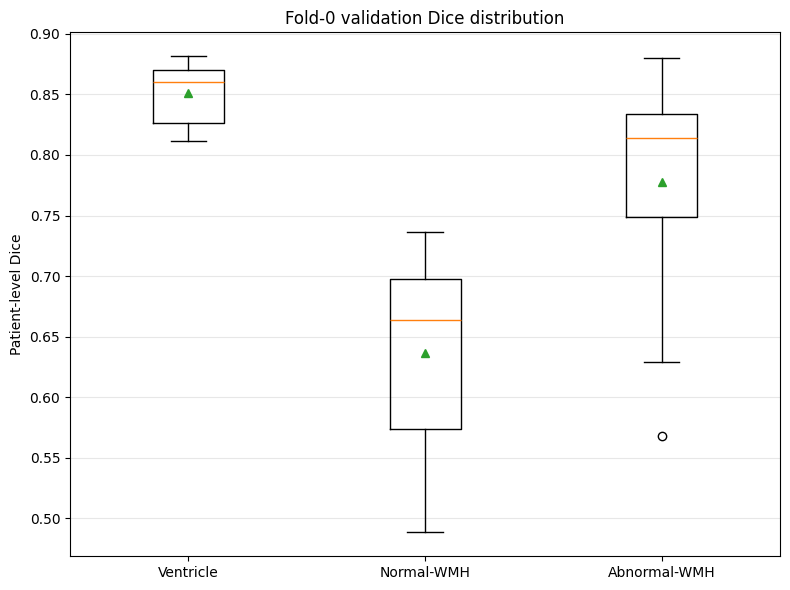

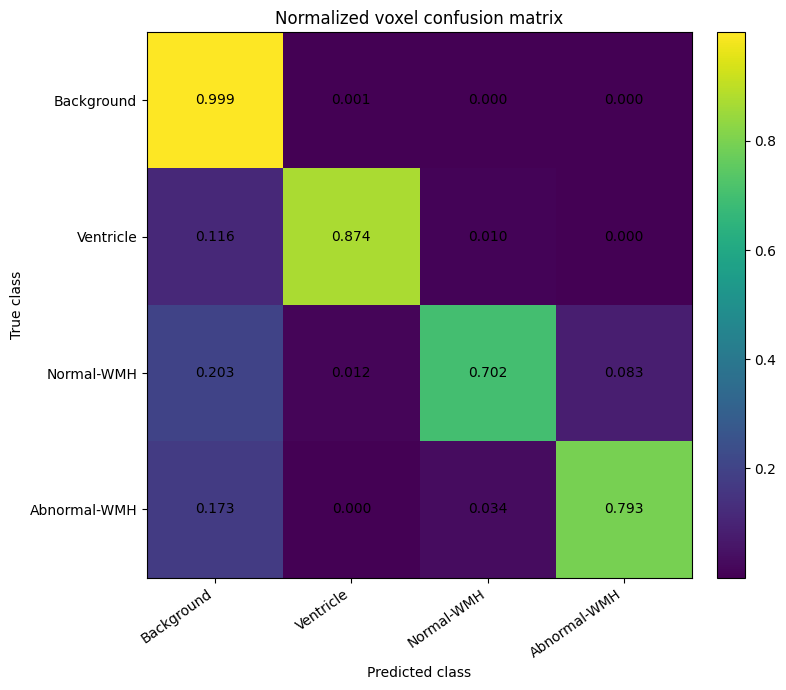

In [18]:
class_labels = [
    "Ventricle",
    "Normal-WMH",
    "Abnormal-WMH",
]

dice_columns = [
    "ventricle_dice",
    "normal_wmh_dice",
    "abnormal_wmh_dice",
]

figure = plt.figure(
    figsize=(
        8,
        6,
    )
)

plt.boxplot(
    [
        patient_metrics_df[
            column
        ].dropna().values
        for column
        in dice_columns
    ],
    labels=class_labels,
    showmeans=True,
)

plt.ylabel(
    "Patient-level Dice"
)

plt.title(
    "Fold-0 validation Dice distribution"
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "fold0_validation_dice_boxplot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


normalized_confusion = (
    global_confusion
    / np.maximum(
        global_confusion.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
)

figure = plt.figure(
    figsize=(
        8,
        7,
    )
)

image = plt.imshow(
    normalized_confusion,
    interpolation="nearest",
)

plt.colorbar(
    image,
    fraction=0.046,
    pad=0.04,
)

axis_labels = [
    "Background",
    "Ventricle",
    "Normal-WMH",
    "Abnormal-WMH",
]

plt.xticks(
    range(4),
    axis_labels,
    rotation=35,
    ha="right",
)

plt.yticks(
    range(4),
    axis_labels,
)

plt.xlabel(
    "Predicted class"
)

plt.ylabel(
    "True class"
)

plt.title(
    "Normalized voxel confusion matrix"
)

for row_index in range(4):
    for column_index in range(4):
        plt.text(
            column_index,
            row_index,
            f"{normalized_confusion[row_index, column_index]:.3f}",
            ha="center",
            va="center",
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "fold0_validation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Worst patient: 017
Median patient: 099
Best patient: 034


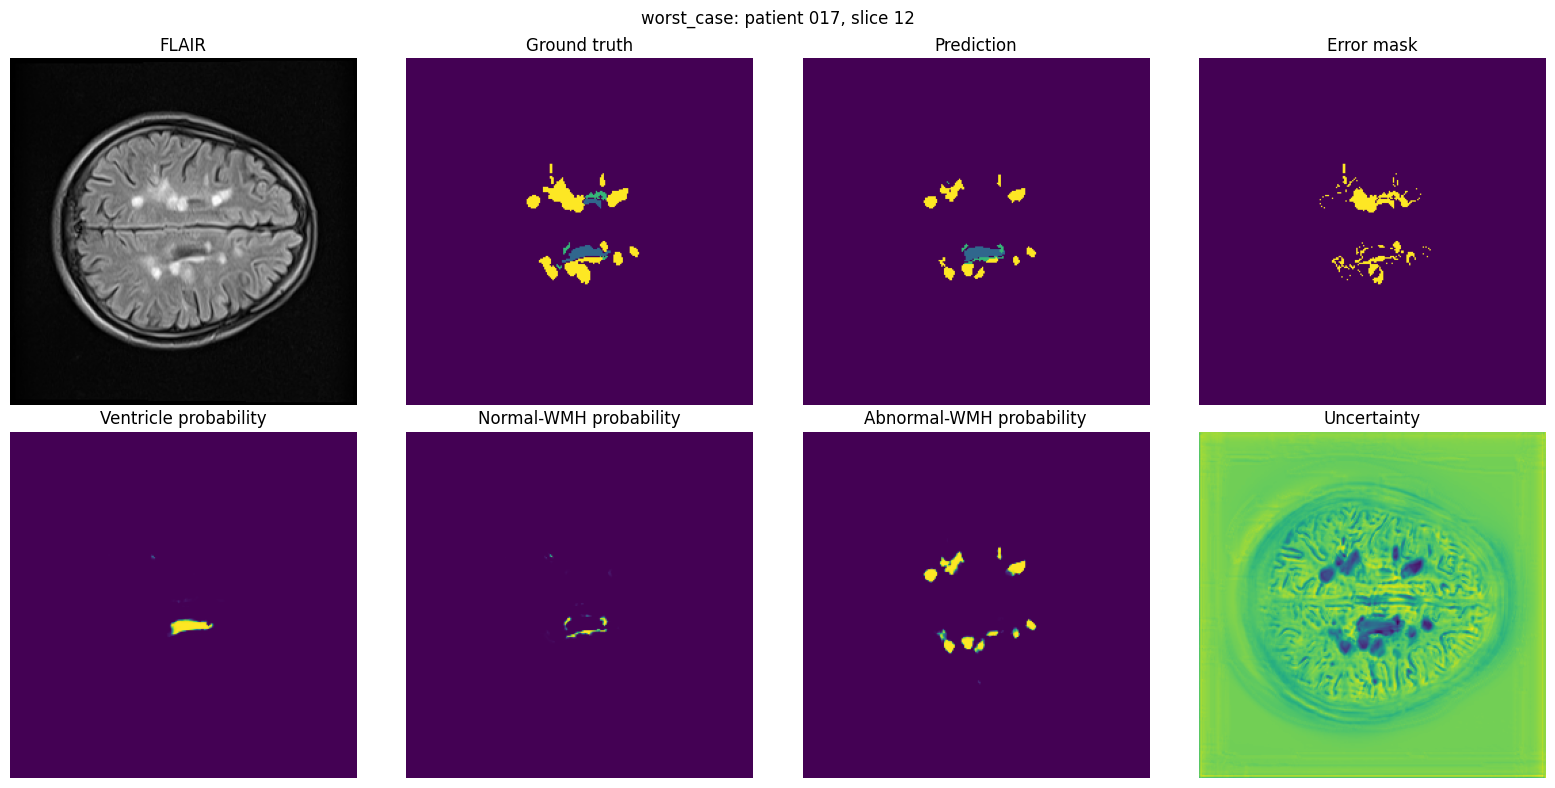

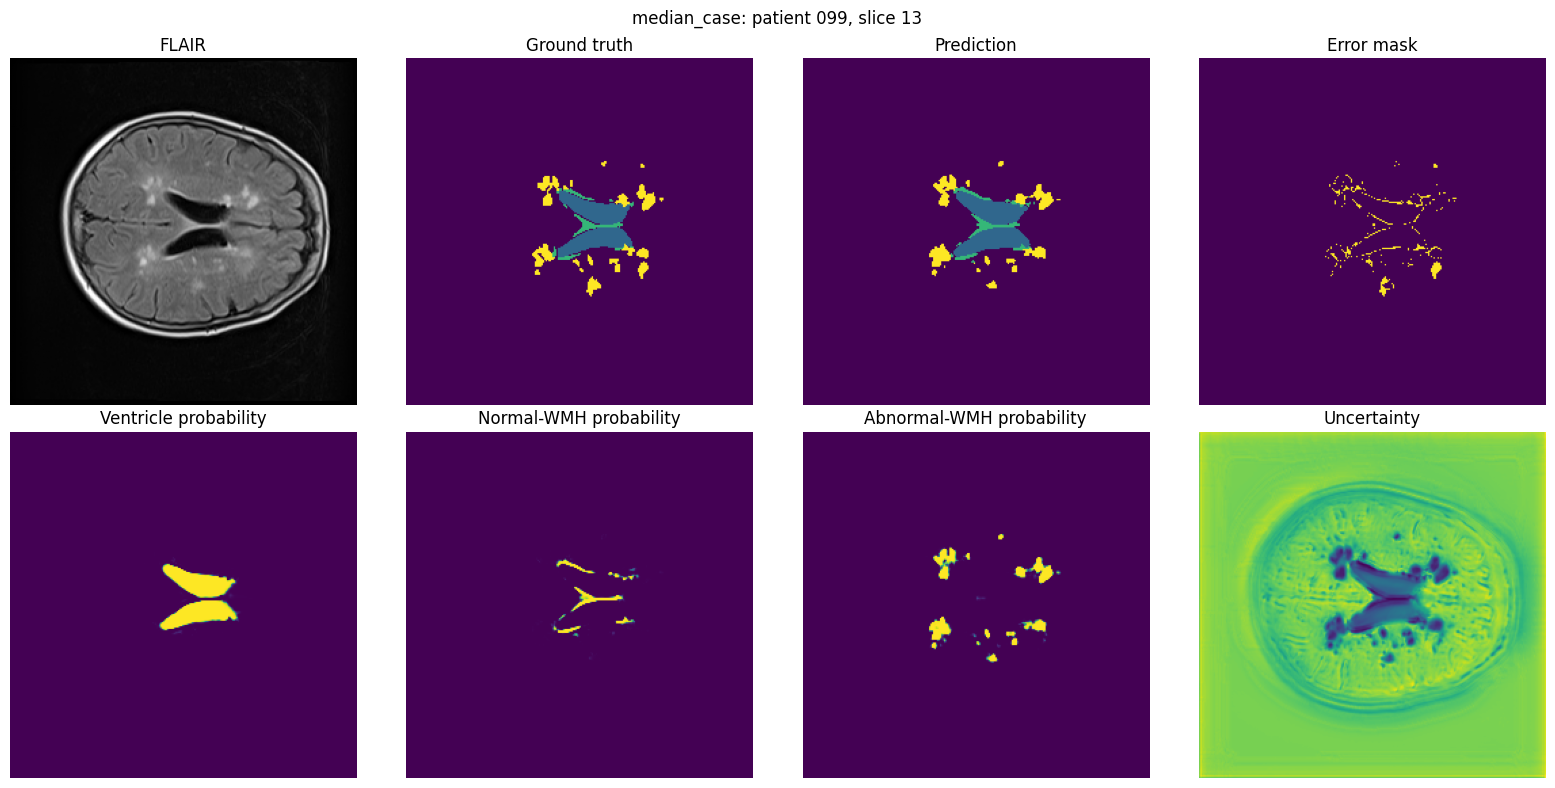

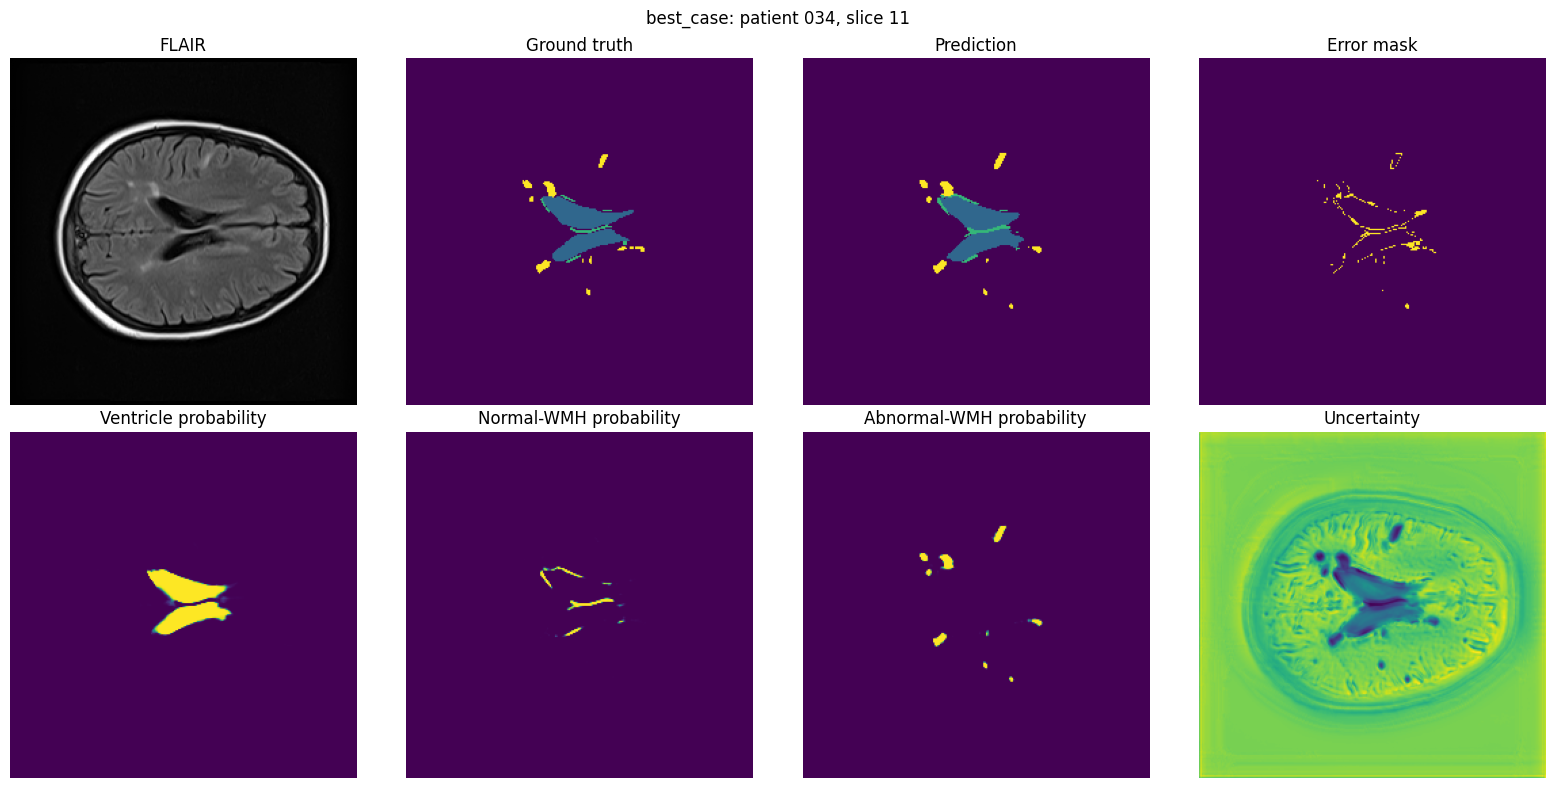

In [19]:
def select_representative_slice(
    target,
    prediction,
):
    abnormal_burden = (
        target
        == 3
    ).sum(
        axis=(
            0,
            1,
        )
    )

    error_burden = (
        target
        != prediction
    ).sum(
        axis=(
            0,
            1,
        )
    )

    combined_score = (
        abnormal_burden
        + 0.25
        * error_burden
    )

    return int(
        np.argmax(
            combined_score
        )
    )


def save_qualitative_figure(
    patient_id,
    label,
):
    cached = validation_cache[
        patient_id
    ]

    row = manifest_by_id.loc[
        patient_id
    ]

    flair = load_normalized_volume(
        row.flair
    )

    target = cached[
        "target"
    ]

    prediction = cached[
        "prediction"
    ]

    probabilities = cached[
        "probabilities"
    ].astype(np.float32)

    uncertainty = cached[
        "uncertainty"
    ].astype(np.float32)

    slice_index = select_representative_slice(
        target,
        prediction,
    )

    error = (
        prediction
        != target
    )

    figure, axes = plt.subplots(
        2,
        4,
        figsize=(
            16,
            8,
        ),
    )

    images = [
        flair[
            :,
            :,
            slice_index,
        ],
        target[
            :,
            :,
            slice_index,
        ],
        prediction[
            :,
            :,
            slice_index,
        ],
        error[
            :,
            :,
            slice_index,
        ],
        probabilities[
            :,
            :,
            slice_index,
            1,
        ],
        probabilities[
            :,
            :,
            slice_index,
            2,
        ],
        probabilities[
            :,
            :,
            slice_index,
            3,
        ],
        uncertainty[
            :,
            :,
            slice_index,
        ],
    ]

    titles = [
        "FLAIR",
        "Ground truth",
        "Prediction",
        "Error mask",
        "Ventricle probability",
        "Normal-WMH probability",
        "Abnormal-WMH probability",
        "Uncertainty",
    ]

    for axis, image_data, title in zip(
        axes.ravel(),
        images,
        titles,
    ):
        axis.imshow(
            image_data,
            cmap=(
                "gray"
                if title
                == "FLAIR"
                else None
            ),
        )

        axis.set_title(
            title
        )

        axis.axis(
            "off"
        )

    figure.suptitle(
        f"{label}: patient {patient_id}, slice {slice_index}"
    )

    plt.tight_layout()

    output_path = (
        FIGURE_DIR
        / f"{label}_{patient_id}_slice_{slice_index}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


ranking = patient_metrics_df.sort_values(
    "mean_foreground_dice"
)

worst_patient = ranking.iloc[
    0
].patient_id

median_patient = ranking.iloc[
    len(ranking)
    // 2
].patient_id

best_patient = ranking.iloc[
    -1
].patient_id

print("Worst patient:", worst_patient)
print("Median patient:", median_patient)
print("Best patient:", best_patient)

save_qualitative_figure(
    worst_patient,
    "worst_case",
)

save_qualitative_figure(
    median_patient,
    "median_case",
)

save_qualitative_figure(
    best_patient,
    "best_case",
)

In [20]:
metadata = {
    "model": "VentiMorph-RelNet-v2.7",
    "checkpoint": str(
        CHECKPOINT_PATH
    ),
    "checkpoint_best_epoch": checkpoint.get(
        "best_epoch"
    ),
    "dataset_root": str(
        DATA_ROOT
    ),
    "split_file": str(
        SPLIT_PATH
    ),
    "fold": FOLD,
    "evaluated_split": "validation",
    "evaluated_patients": validation_ids,
    "locked_test_evaluated": False,
    "classes": {
        "0": "background",
        "1": "ventricle",
        "2": "normal_WMH",
        "3": "abnormal_WMH",
    },
    "inference": {
        "decision_rule": "softmax argmax",
        "batch_size": INFERENCE_BATCH_SIZE,
        "postprocessing": "none",
    },
    "lesion_matching": {
        "connectivity": "3D scipy structure rank 2",
        "minimum_component_voxels": 3,
        "one_to_one_matching": "Hungarian assignment",
        "iou_threshold": 0.10,
        "exploratory_size_groups_voxels": {
            "small": "3-20",
            "medium": "21-100",
            "large": ">100",
        },
    },
}

with open(
    OUTPUT_DIR
    / "evaluation_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

print(
    json.dumps(
        metadata,
        indent=2,
    )
)

{
  "model": "VentiMorph-RelNet-v2.7",
  "checkpoint": "/kaggle/input/datasets/saifsoft/ms3seg-v27-best-checkpoint/best_model.pt",
  "checkpoint_best_epoch": 47,
  "dataset_root": "/kaggle/input/datasets/saifsamiul/ms3seg/MS3SEG",
  "split_file": "/kaggle/input/datasets/saifsoft/ms3seg-v27-best-checkpoint/patient_level_5fold_split.csv",
  "fold": 0,
  "evaluated_split": "validation",
  "evaluated_patients": [
    "001",
    "007",
    "017",
    "018",
    "023",
    "034",
    "048",
    "053",
    "062",
    "064",
    "070",
    "072",
    "086",
    "089",
    "095",
    "099"
  ],
  "locked_test_evaluated": false,
  "classes": {
    "0": "background",
    "1": "ventricle",
    "2": "normal_WMH",
    "3": "abnormal_WMH"
  },
  "inference": {
    "decision_rule": "softmax argmax",
    "batch_size": 4,
    "postprocessing": "none"
  },
  "lesion_matching": {
    "connectivity": "3D scipy structure rank 2",
    "minimum_component_voxels": 3,
    "one_to_one_matching": "Hungarian assig

In [21]:
import shutil

archive_path = shutil.make_archive(
    "/kaggle/working/MS3SEG_V27_FOLD0_VALIDATION_RESULTS",
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Evaluation archive created:")
print(archive_path)

print("\nDownload this file before leaving Kaggle:")
print("/kaggle/working/MS3SEG_V27_FOLD0_VALIDATION_RESULTS.zip")

Evaluation archive created:
/kaggle/working/MS3SEG_V27_FOLD0_VALIDATION_RESULTS.zip

Download this file before leaving Kaggle:
/kaggle/working/MS3SEG_V27_FOLD0_VALIDATION_RESULTS.zip


## After this notebook finishes

Upload the executed notebook or the generated results ZIP for review.

Do not evaluate the locked-test patients yet. The next decision will be based on:

- patient-level Dice stability;
- HD95 and ASSD;
- lesion-level F1;
- small-lesion recall;
- normal-WMH versus abnormal-WMH confusion;
- periventricular false positives;
- best/worst qualitative cases.